In [1]:
#import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Import Dataset
df = pd.read_excel(r"C:\Users\Meg\Desktop\CVTC\MchLrng\M9\cars.xlsx")
df.head

# Convert non-metric data using one-hot encoding
df =pd.get_dummies(df, dtype=int)
df.head

# Assign X and y variables
X = df.drop(['car_ID','price'],axis=1)
y = df['price']

# Split data into test/train set (70/30 split) and shuffle
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, shuffle=True)

# Assign Algorithm
model = LinearRegression()

# Link Aglorithm to X and y variables
model.fit(X_train, y_train)

# Find y-intercept
model.intercept_

# Find X coefficients
model.coef_

array([-7.48469021e+02,  3.10618518e+02, -1.13945452e+02, -6.27098004e+02,
       -1.14946553e+03,  1.04344841e+01,  1.42341251e+02, -3.87686022e+03,
       -8.15722690e+02, -1.67834106e+03, -1.08634290e+02,  1.39961042e+00,
       -1.91895544e+02,  2.05968583e+02, -8.07361727e+02,  5.76813008e+03,
       -5.12865558e+03, -2.12365558e+03,  7.05831277e+03, -1.44990508e-09,
        4.96195393e+03,  1.48458005e+03, -4.17321644e-09, -5.51819075e+03,
        7.12619202e+03,  4.98196963e+03,  4.85442797e-10, -2.63457878e-09,
        1.93875872e+04,  1.24691724e-09,  3.75679287e+03,  1.15778676e-09,
       -3.73671698e+03,  2.18950847e+02, -5.41149348e-11,  5.55391269e+03,
        3.84789959e+03, -1.97293063e+03, -2.17167292e+02, -1.43884000e+03,
       -3.14584708e+03, -9.79980541e-11, -4.74544091e+03, -5.66244091e+03,
       -9.67541033e+03, -3.22758494e+03, -7.55914277e+03,  2.13437072e+02,
       -4.06588030e+03, -3.09228199e-11,  2.91038305e-11, -1.14096124e+03,
       -2.16495364e+02,  

In [2]:
mae_train = mean_absolute_error(y_train, model.predict(X_train))
print("Train data: %.2f" % mae_train)

mae_test = mean_absolute_error(y_test, model.predict(X_test))
print("Test data: %.2f" % mae_test)

Train data: 72.98
Test data: 3464.48


In [7]:
import numpy as np

car = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

car['symboling'] = 3
car['wheelbase'] = 88.6
car['carlength'] = 168.8
car['carwidth'] = 64.1
car['carheight'] = 48.8
car['curbweight'] = 2548
car['enginesize'] = 130
car['boreratio'] = 3.47
car['stroke'] = 2.68
car['compressionratio'] = 9.0
car['horsepower'] = 111
car['peakrpm'] = 5000
car['citympg'] = 21
car['highwaympg'] = 27

car['fueltype_gas'] = 1
car['aspiration_std'] = 1
car['doornumber_two'] = 1
car['drivewheel_fwd'] = 1
car['enginelocation_front'] = 1

prediction = model.predict(car)
print(prediction)

[19617.45474884]


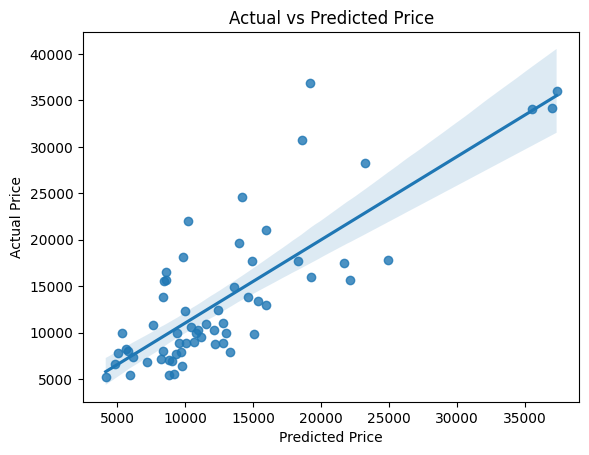

In [8]:
pred = model.predict(X_test)

sns.regplot(x=pred, y=y_test)
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("Actual vs Predicted Price")
plt.show()